# **Task 04 – Exploratory Data Analysis**
### **SmartCare Hospital AI Dataset | Option C – Disease Risk Classification**

**Source:** raw dataset only (`data/raw/smartcare_ai_dataset_1000.csv`) — not the
Task 03 processed splits. This notebook is descriptive: no scaling, encoding,
feature selection, or modeling occurs here.

**Note on correlation:** correlation indicates linear association only, not
causation or guaranteed predictive importance. A variable is never called a
"strong predictor" in this notebook based on correlation alone.

## **4.2 Dataset Overview**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
PROJECT_ROOT = Path.cwd().parent
df = pd.read_csv(PROJECT_ROOT / 'data' / 'raw' / 'smartcare_ai_dataset_1000.csv')

print(f"Shape: {df.shape}")
df.head()

Shape: (1000, 33)


,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,...,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
0,1,P10001,53,Male,A-,General Medicine,Migraine,2025-04-10,10,1,...,2000,0,0,11596,13596,Paid,Insurance,0,0,High
1,2,P10002,26,Male,B-,General Medicine,Diabetes,2025-05-15,2,3,...,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,2025-07-09,22,7,...,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium
3,4,P10004,44,Female,AB-,Cardiology,Asthma,2025-10-16,16,1,...,2000,0,5000,10262,17262,Paid,Online,0,0,Medium
4,5,P10005,51,Female,O+,Neurology,Hypertension,2025-12-18,12,4,...,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium


## **4.3 Data Types and Descriptive Statistics**
Focus on the main clinical variables named in the coursework scope.

In [2]:
df.dtypes

record_id                         int64
patient_id                       object
age                               int64
gender                           object
blood_group                      object
department                       object
diagnosis                        object
appointment_date                 object
waiting_days                      int64
previous_appointments             int64
missed_previous_appointments      int64
appointment_status               object
admitted                          int64
room_type                        object
length_of_stay_days               int64
previous_admissions               int64
systolic_bp                       int64
diastolic_bp                      int64
blood_sugar_mg_dl                 int64
cholesterol_mg_dl                 int64
bmi                             float64
lab_tests_count                   int64
treatments_count                  int64
consultation_fee_lkr              int64
room_charge_lkr                   int64


In [3]:
clinical_cols = ['age', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi']
df[clinical_cols].describe().round(2)

,age,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,44.74,128.42,78.83,114.83,204.81,25.52
std,17.85,15.49,10.04,26.02,36.65,4.25
min,1.00,85.00,50.00,65.00,100.00,14.00
25%,33.00,117.00,72.00,97.00,180.00,22.70
50%,44.00,128.00,79.00,114.00,204.00,25.60
75%,57.00,139.00,86.00,132.00,230.00,28.30
max,90.00,178.00,111.00,201.00,330.00,38.80


**Interpretation:** Age ranges from 1–90 years (mean 44.74). Systolic blood pressure ranges from 85–178 mmHg (mean 128.42), while diastolic blood pressure ranges from 50–111 mmHg (mean 78.83). Blood sugar ranges from 65–201 mg/dL (mean 114.83), cholesterol from 100–330 mg/dL (mean 204.81), and BMI from 14.0–38.8 (mean 25.52). The variables show substantial variation across the dataset, providing sufficient variability for further distribution, correlation, and pattern analysis.

## **4.4 Data Quality Overview**
Recap only — findings already established in Task 02/03, not re-fixed here.

In [4]:
print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values:
 room_type    906
dtype: int64

Duplicate rows: 0


**Interpretation:** `room_type` has 906 missing values, all attributable to
non-admitted patients (established in Task 02/03 — not re-derived here). No
duplicate rows exist.

## **4.5 Target/Class Distribution**

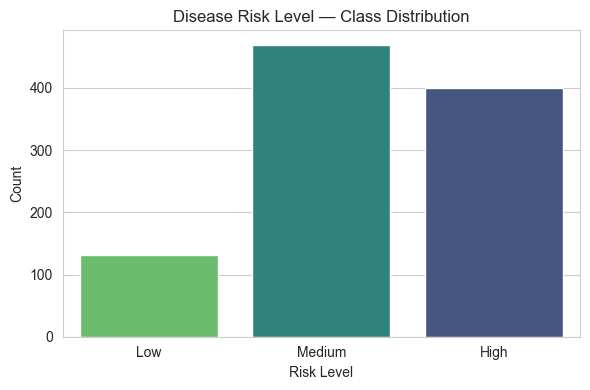

,count,percent
disease_risk_level,,
Medium,469,46.9
High,400,40.0
Low,131,13.1


In [5]:
target_counts = df['disease_risk_level'].value_counts()
target_pct = df['disease_risk_level'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='disease_risk_level', order=['Low', 'Medium', 'High'],
              hue='disease_risk_level', palette='viridis', legend=False, ax=ax)
ax.set_title('Disease Risk Level — Class Distribution')
ax.set_xlabel('Risk Level')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

pd.DataFrame({'count': target_counts, 'percent': target_pct.round(1)})

**Interpretation:** Medium is the majority class (46.9%), followed by High
(40.0%) and Low (13.1%). Low is meaningfully underrepresented — worth
flagging for Task 05 (e.g. class weighting), though that decision is out of
scope here.

## **4.6 Distribution Analysis**
Histograms for the six clinical variables.

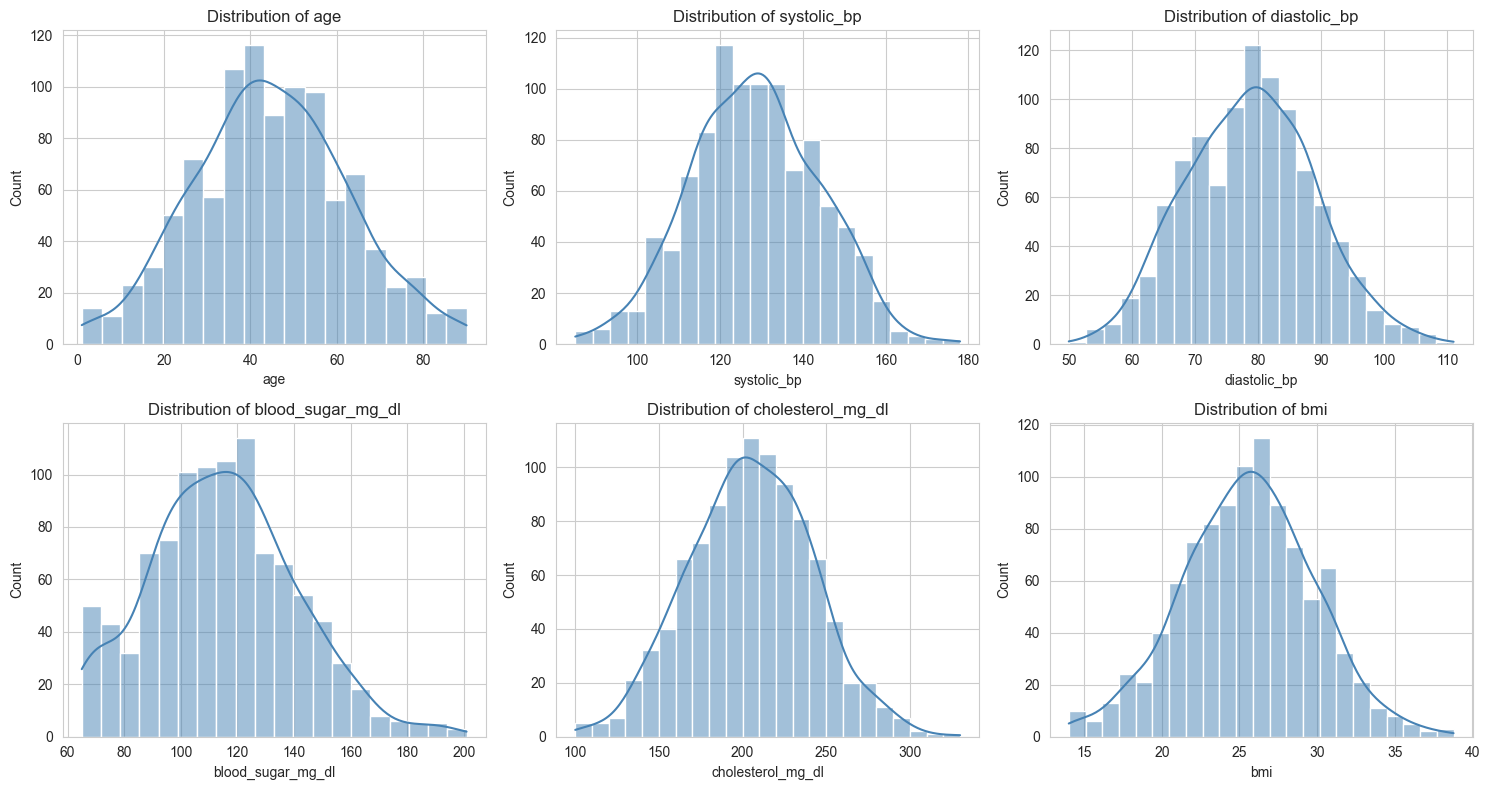

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, clinical_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

**Interpretation:** `age`, `systolic_bp`, `diastolic_bp`, `cholesterol_mg_dl`,
and `bmi` are approximately unimodal and roughly symmetric. `blood_sugar_mg_dl`
shows a visible right-leaning spread toward higher values, consistent with a
subset of patients with elevated readings.

## **4.7 Outlier Analysis**
IQR-based bounds, calculated on the raw dataset for exploratory purposes
(no rows are removed — Task 03 handles cleaning decisions separately).

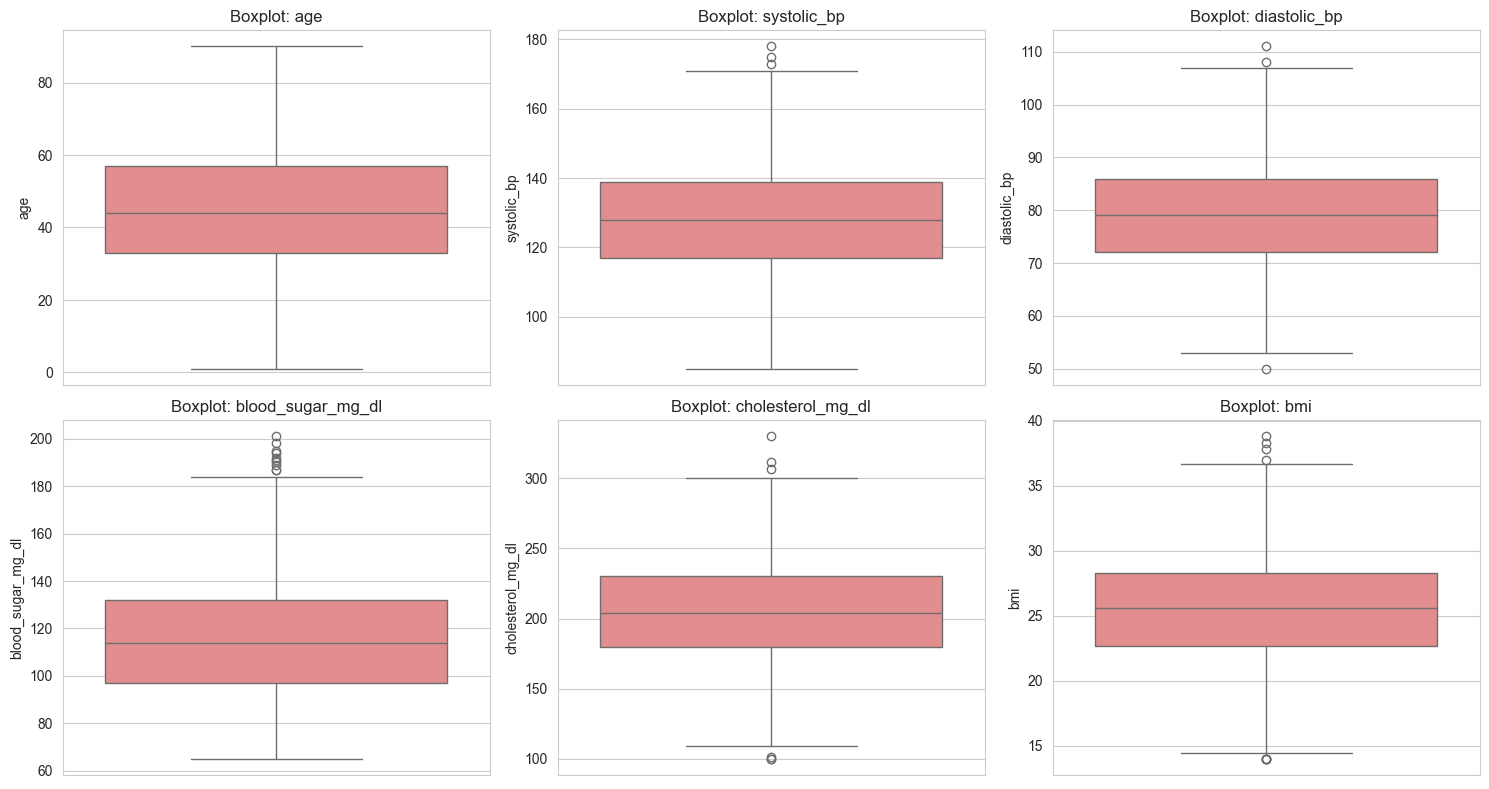

age                  | bounds=(-3.0, 93.0) | outliers=0
systolic_bp          | bounds=(84.0, 172.0) | outliers=3
diastolic_bp         | bounds=(51.0, 107.0) | outliers=3
blood_sugar_mg_dl    | bounds=(44.5, 184.5) | outliers=10
cholesterol_mg_dl    | bounds=(105.0, 305.0) | outliers=6
bmi                  | bounds=(14.3, 36.7) | outliers=9


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, clinical_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

for col in clinical_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col:20s} | bounds=({lower:.1f}, {upper:.1f}) | outliers={n_out}")

**Interpretation:** Outlier counts are low across all six variables
(0–10 out of 1000 rows). `age` has none; `blood_sugar_mg_dl` has the most
(10). These values are within physiologically plausible ranges (e.g. max
blood sugar 201 mg/dL) and are not treated as errors here — this observation
aligns with the Task 03 decision to retain them rather than cap or remove.

## **4.8 Correlation Analysis**
The target is temporarily ordinal-encoded (Low=0, Medium=1, High=2) **only
for this exploratory correlation view** — this encoding is not saved or
reused anywhere else in this notebook.

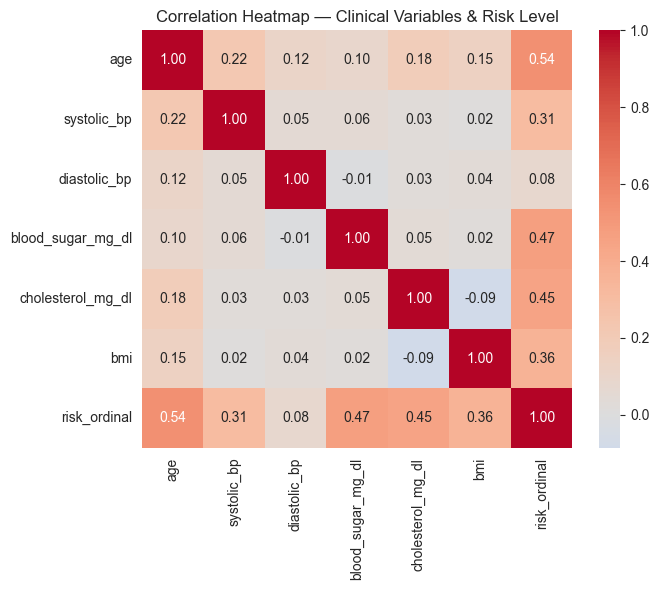

age                  0.537582
blood_sugar_mg_dl    0.474440
cholesterol_mg_dl    0.446766
bmi                  0.359904
systolic_bp          0.310525
diastolic_bp         0.084029
Name: risk_ordinal, dtype: float64

In [8]:
df_corr = df.copy()
df_corr['risk_ordinal'] = df_corr['disease_risk_level'].map({'Low': 0, 'Medium': 1, 'High': 2})

corr_matrix = df_corr[clinical_cols + ['risk_ordinal']].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap — Clinical Variables & Risk Level')
plt.tight_layout()
plt.show()

corr_matrix['risk_ordinal'].drop('risk_ordinal').sort_values(ascending=False)

**Interpretation:** `age` (r=0.54), `blood_sugar_mg_dl` (r=0.47), and
`cholesterol_mg_dl` (r=0.45) show a moderate-to-strong linear association
with the ordinal-encoded target; `bmi` (r=0.36) and `systolic_bp` (r=0.31)
show weaker association; `diastolic_bp` (r=0.08) shows almost none. Among
the clinical predictors themselves, inter-correlations are low (all |r|
< 0.25), suggesting limited multicollinearity. These are linear associations
with an ordinal encoding chosen for exploration — they do not establish
predictive importance for any specific model and should not be treated as
a ranking of "strong predictors."

## **4.9 Scatterplot and Relationship Analysis**
Variables selected based on the two highest correlations with the ordinal
target from Section 4.8 (`age`, `blood_sugar_mg_dl`), plus `bmi` as a
commonly discussed clinical risk factor — not all 15 possible pairs are
plotted, to keep the analysis focused.

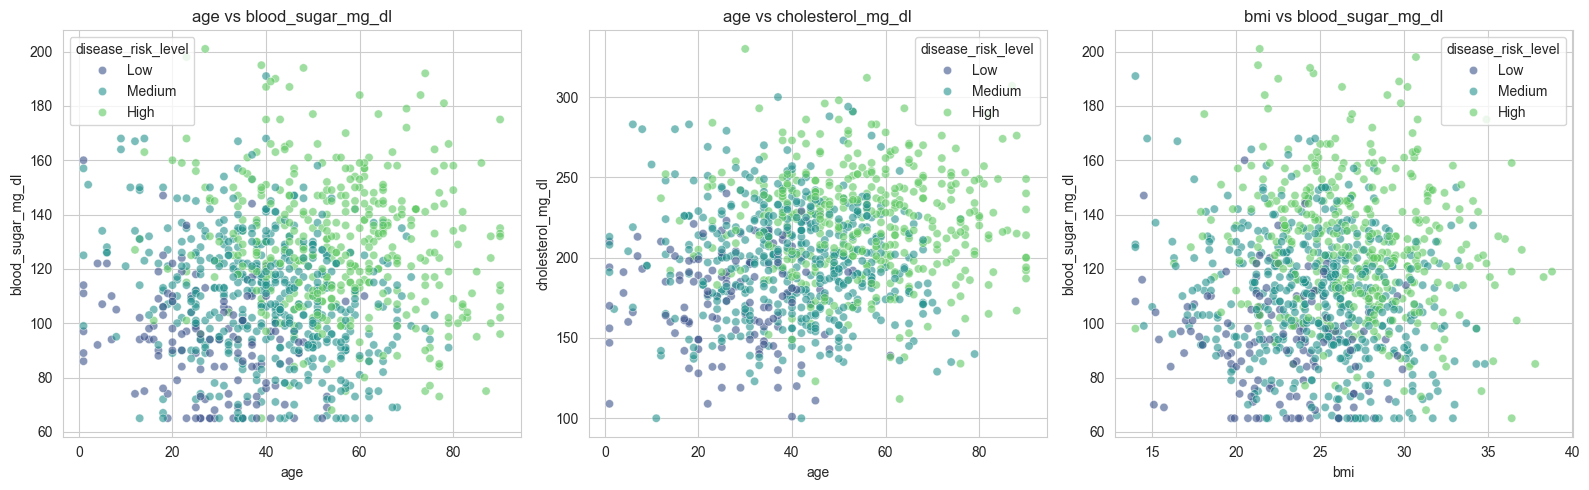

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs = [('age', 'blood_sugar_mg_dl'), ('age', 'cholesterol_mg_dl'), ('bmi', 'blood_sugar_mg_dl')]
for ax, (x, y) in zip(axes, pairs):
    sns.scatterplot(data=df, x=x, y=y, hue='disease_risk_level',
                     hue_order=['Low', 'Medium', 'High'], palette='viridis', alpha=0.6, ax=ax)
    ax.set_title(f'{x} vs {y}')
plt.tight_layout()
plt.show()

## **4.10 Pattern Discovery**

In [10]:
df.groupby('disease_risk_level')[clinical_cols].mean().round(2).loc[['Low', 'Medium', 'High']]

,age,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi
disease_risk_level,,,,,,
Low,27.56,121.11,76.64,93.31,174.22,22.63
Medium,40.49,125.57,78.83,109.04,198.28,24.92
High,55.36,134.16,79.54,128.67,222.50,27.16


In [11]:
pd.crosstab(df['gender'], df['disease_risk_level'], normalize='index').round(3) * 100

disease_risk_level,High,Low,Medium
gender,,,
Female,41.1,13.4,45.5
Male,38.9,12.8,48.3


**Interpretation:**
- Mean values increase monotonically from Low → Medium → High across all
  six clinical variables (e.g. mean age: 27.6 → 40.5 → 55.4; mean blood
  sugar: ~93 → ~109 → ~129 — exact values in the table above). This
  monotonic pattern across every clinical variable is a notable
  characteristic of this dataset and may indicate the target was generated
  using a rule-based combination of these variables — however, the exact
  generation mechanism is undocumented (per Task 02), so this remains an
  observation, not a confirmed mechanism.
- `gender` shows near-identical risk-level proportions between Male and
  Female (e.g. High: 38.9% male vs 41.1% female), suggesting little
  association between gender and risk level in this dataset.
- **Engineered features** (`bp_category`, `bmi_category`, `blood_sugar_category`,
  `age_group`, `health_burden_score`, created in Task 03) are derived,
  exploratory variables. Their relationship to the target is not evaluated
  here, and no claim is made about whether they improve model performance —
  that question belongs to Task 05 model comparison.

## **4.11 Key EDA Findings**

**Observations supported by this analysis:**
- Class imbalance: Medium 46.9%, High 40.0%, Low 13.1% — Low is underrepresented.
- No duplicate rows; `room_type` missingness (906) is structural, per Task 02/03.
- Outlier counts are low (0–10 per clinical variable) and within plausible ranges.
- `age`, `blood_sugar_mg_dl`, and `cholesterol_mg_dl` show the strongest linear
  association with the ordinal-encoded target (r = 0.54, 0.47, 0.45); `diastolic_bp`
  shows almost none (r = 0.08).
- All six clinical variables show monotonically increasing means from
  Low → Medium → High, a pattern consistent across every variable examined —
  worth further investigation in modeling, but the target-generation
  mechanism itself remains undocumented.
- Gender shows little association with risk level in this dataset.

**Explicit limitations:**
- Dataset is synthetic (per Task 02); patterns here reflect this dataset's
  construction, not necessarily real clinical relationships, and no clinical
  validity or generalizability is claimed.
- Correlation values reflect linear association only; non-linear relationships
  are not assessed in this notebook.
- No claim is made about which model or algorithm will perform best, or
  whether engineered features will improve performance — both require
  Task 05 modeling to evaluate.